**PROJECT MSCI 623**

**Air Quality Analysis and Prediction using with Machine learning**

Anjali Anadkat (20861897)

Yogda Gharat  (20848008)

**Importing Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from fancyimpute import IterativeImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

import itertools
%matplotlib inline

In [141]:
from google.colab import files
data_to_load = files.upload()

Saving city_day.csv to city_day (3).csv


In [288]:
import io
main = pd.read_csv(io.BytesIO(data_to_load['city_day.csv']))
main.head()
m1=main.copy()
m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28840 entries, 0 to 28839
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        28840 non-null  object 
 1   Date        28840 non-null  object 
 2   PM2.5       24250 non-null  float64
 3   PM10        17795 non-null  float64
 4   NO          25313 non-null  float64
 5   NO2         25266 non-null  float64
 6   NOx         24659 non-null  float64
 7   NH3         18635 non-null  float64
 8   CO          26784 non-null  float64
 9   SO2         24989 non-null  float64
 10  O3          24821 non-null  float64
 11  Benzene     23220 non-null  float64
 12  Toluene     20802 non-null  float64
 13  Xylene      11300 non-null  float64
 14  AQI         24201 non-null  float64
 15  AQI_Bucket  24201 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.5+ MB


In [ ]:
#Correlation of numeric variables with AQI
corr_with_AQI = m1.corr().AQI.sort_values(ascending = False)
corr_with_AQI

**Checking the data distribution for all the numeric variables**

In [ ]:
columns = m1.columns[3:15]
plt.subplots(figsize=(9,9))
length =len(columns)
for i,j in itertools.zip_longest(columns,range(length)):
    plt.subplot((length/2),3,j+1)
    plt.subplots_adjust(wspace=0.7,hspace=0.7)
    plt.ylabel("Count")
    sns.distplot(m1[i].dropna())
    #plt.title(i)
plt.show()

In [ ]:
m1.kurtosis()

**Handling Missing Values**

In [ ]:
#Checking Missing values
def missing_values_table(m1):

        #Total values
        val =m1.count()
        # Total missing values
        mis = m1.isnull().sum()
        
        # Percentage of missing values
        mis_percent = 100 * m1.isnull().sum() / len(m1)
        
        # Make a table with the results
        mis_table = pd.concat([mis,val, mis_percent], axis=1)
        
        # Rename the columns
        mis_table_columns = mis_table.rename(
        columns = { 0: 'Missing Values', 1 : 'Existing Values', 2 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_table_columns = mis_table_columns[
            mis_table_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_table_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_table_columns

missing_values= missing_values_table(m1)
missing_values.style.background_gradient(cmap='Blues')

**Using MICE Imputation to handle missing values.**

Missing data are a common problem in psychiatric research. Multivariate imputation by chained equations (MICE), sometimes called “fully conditional specification” or “sequential regression multiple imputation” has emerged in the statistical literature as one principled method of addressing missing data. 


The missing data for categorial variable "AQI_Bucket" is handled using domain knowledge.

In [ ]:
#Using MICE Imputer to handle missing values

mice_imputer = IterativeImputer()

imputing_cols = [ 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2','O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
# we eliminated city, date, Year_Month and AQI_Bucket because 
# they either were unique or had numerical substitude in other fields(AQI_bucket)
m2 = m1.copy()
mice_imputer.fit(m2[imputing_cols])

imputed = mice_imputer.transform(m2[imputing_cols])

m2.loc[:, imputing_cols] = imputed

#Handling missing value for the categorical variable "AQI_Bucket"

def get_remark(aqi_val):
    if 0<=aqi_val<=50:
        return 'Good'
    if 51<=aqi_val<=100:
        return 'Satisfactory'
    if 101<=aqi_val<=200:
        return 'Moderate'
    if 201<=aqi_val<=300:
        return 'Poor'
    if 301<=aqi_val<=400:
        return 'Very Poor'
    else:
        return 'Severe'
    
m2['AQI_Bucket'] = m2['AQI'].map(get_remark)


All the missing values are now handled. 

**FEATURE** **ENGINEERING**

We will use Recursive Feature elimination for feature selection.

**Recursive feature elimination (RFE)** is a feature selection method that fits a model and removes the weakest feature (or features) until the specified number of features is reached. RFE requires a specified number of features to keep, however it is often not known in advance how many features are valid. To find the optimal number of features** cross-validation is used with RFE** to score different feature subsets and select the best scoring collection of features.

In [16]:
#Spliting the data

df = m2.copy()

x = df.drop(['City', 'Date', 'AQI', 'Year', 'AQI_Bucket', 'Month'], axis = 1)
y = df.AQI_Bucket

x1 = x.copy()
x1_train, x1_test, y1_train, y1_test =  train_test_split(x1,y,test_size=0.2, random_state = 27) 

In [9]:
#Building a performance Measure function

def generate_perform_measures(model, x, y):
    ac = accuracy_score(y,model.predict(x))
    f_score = f1_score(y,model.predict(x), average='weighted' )
    prec = precision_score(y,model.predict(x), average='weighted')
    re = recall_score(y,model.predict(x), average='weighted')
    print('Accuracy is: ', ac)
    print('F1 score is: ', f_score)
    print('Precision is: ', prec)
    print('Recall is: ', re)

    return 

In [ ]:
#Baseline Model used for the comparison of the RFECV results

#Baseline Logistic Regression Model
rfe_base = LogisticRegression(multi_class= 'multinomial') 

base_model = rfe_base.fit(x1_train,y1_train)

base_model.score(x1_test, y1_test)

**RECURSIVE FEATURE ENGINEERING**

In [ ]:
#Recursive Feature Engineering
from sklearn.feature_selection import RFE
rfe = RFE(estimator=rfe_base, step=1)
rfe = rfe.fit(x1_train, y1_train)

In [ ]:

selected_rfe_features = pd.DataFrame({'Feature':list(x1_train.columns),
                                      'Ranking':rfe.ranking_})
selected_rfe_features.sort_values(by='Ranking')

In [29]:
x1_train_rfe = rfecv.transform(x1_train)
x1_test_rfe = rfecv.transform(x1_test)

In [30]:
#Model for RFE
rfe_log = LogisticRegression(multi_class= 'multinomial')  
rfe_log.fit(x1_train_rfe, y1_train)

rfe_log.score(x1_test_rfe, y1_test)

generate_perform_measures(log, x1_test_rfe, y1_test)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


Accuracy is:  0.6019417475728155
F1 score is:  0.5710582072521134
Precision is:  0.5631344271519257
Recall is:  0.6019417475728155


**RECURSIVE FEATURE ENGINEERING WITH CROSS VALIDATION**

In [ ]:
#Recursive Feature engineering with cross validation

from sklearn.feature_selection import RFECV
rfecv = RFECV(estimator= rfe_base, step=1, cv=5, scoring='accuracy')
rfecv = rfecv.fit(x1_train, y1_train)

In [32]:
print('Optimal number of features :', rfecv.n_features_)
print('Best features :', x1_train.columns[rfecv.support_])

Optimal number of features : 9
Best features : Index(['PM2.5', 'NO', 'NOx', 'NH3', 'CO', 'O3', 'Benzene', 'Toluene',
       'Xylene'],
      dtype='object')


In [17]:
rfecv.grid_scores_

array([0.41262106, 0.41435475, 0.42079518, 0.48861126, 0.56766425,
       0.58866646, 0.59411473, 0.59198476, 0.60015832, 0.59877121,
       0.59634441, 0.59302503])

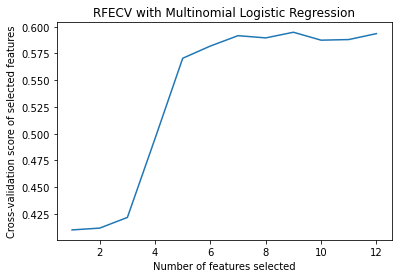

In [37]:
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score of selected features")
plt.title("RFECV with Multinomial Logistic Regression")
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)
plt.show()


In [40]:
#Selecting the features

x1_train_rfecv = rfecv.transform(x1_train)
x1_test_rfecv = rfecv.transform(x1_test)

**SUPERVISED LEARNING**

1. Multinomial Logistic Regression

In [41]:
#Model after feature selection

#Log regression
log = LogisticRegression(multi_class= 'multinomial')  
log_model = log.fit(x1_train_rfecv, y1_train)

log_model.score(x1_test_rfecv, y1_test)

generate_perform_measures(log, x1_test_rfecv, y1_test)

Accuracy is:  0.6019417475728155
F1 score is:  0.5710582072521134
Precision is:  0.5631344271519257
Recall is:  0.6019417475728155


In [57]:
#K fold cross validation for Multinomial Log Regression

from sklearn.model_selection import cross_val_score

acc_log = cross_val_score(estimator = log, X = x1, y=y, cv=10)
print("Average Accuracies: ",np.mean(acc_log))
print("Standart Deviation Accuracies: ",np.std(acc_log))

Average Accuracies:  0.5585644937586685
Standart Deviation Accuracies:  0.03014189462027884


[Text(0, 0.5, 'Good'),
 Text(0, 1.5, 'Satisfactory'),
 Text(0, 2.5, 'Moderate'),
 Text(0, 3.5, 'Poor'),
 Text(0, 4.5, 'Very Poor'),
 Text(0, 5.5, 'Severe')]

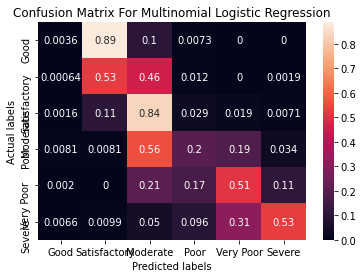

In [289]:
#Confusion Matrix for Multinomial Logistic Regression

y_pred1= log_model.predict(x1_test_rfecv)
y_act1 = y1_test
labels = ['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']
cm = confusion_matrix(y_act1, y_pred1, labels, normalize='true')


ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('Actual labels'); 
ax.set_title('Confusion Matrix For Multinomial Logistic Regression'); 
ax.xaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']); 
ax.yaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe'])

2. Naive Bayes Classification

In [43]:
#Naive Bayes
naivebayes = GaussianNB()

naive = naivebayes.fit(x1_train_rfecv, y1_train)

naive_score = naivebayes.score(x1_test_rfecv,y1_test)
naive_score

generate_perform_measures(naive, x1_test_rfecv, y1_test)

Accuracy is:  0.6783980582524272
F1 score is:  0.6735255708051502
Precision is:  0.6772514917634438
Recall is:  0.6783980582524272


In [58]:
from sklearn.model_selection import cross_val_score

acc_naive = cross_val_score(estimator = naive, X = x1, y=y, cv=10)
print("Average Accuracies: ",np.mean(acc_naive))
print("Standart Deviation Accuracies: ",np.std(acc_naive))

Average Accuracies:  0.6944868238557558
Standart Deviation Accuracies:  0.02238368605251834


[Text(0, 0.5, 'Good'),
 Text(0, 1.5, 'Satisfactory'),
 Text(0, 2.5, 'Moderate'),
 Text(0, 3.5, 'Poor'),
 Text(0, 4.5, 'Very Poor'),
 Text(0, 5.5, 'Severe')]

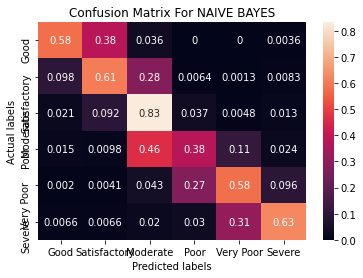

In [290]:
#Confusion Matrix

y_pred1= naive.predict(x1_test_rfecv)
y_actual1 = y1_test
labels = ['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']
cm = confusion_matrix(y_act1, y_pred1, labels, normalize='true')


ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('Actual labels'); 
ax.set_title('Confusion Matrix For NAIVE BAYES'); 
ax.xaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']); 
ax.yaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe'])

3. SVM Classifier

In [47]:
#SVM

svm = SVC(random_state=42)

svm_model = svm.fit(x1_train_rfecv,y1_train)   

svm_score = svm.score(x1_test_rfecv,y1_test)

generate_perform_measures(svm, x1_test_rfecv, y1_test)

Accuracy is:  0.7517337031900139
F1 score is:  0.7347970536998375
Precision is:  0.746862069839438
Recall is:  0.7517337031900139


In [59]:
#K fold cross validation for SVM
from sklearn.model_selection import cross_val_score

acc_svm = cross_val_score(estimator = svm, X = x1, y=y, cv=10)
print("Average Accuracies: ",np.mean(acc_svm))
print("Standart Deviation Accuracies: ",np.std(acc_svm))

Average Accuracies:  0.7503120665742025
Standart Deviation Accuracies:  0.0432494005337023


[Text(0, 0.5, 'Good'),
 Text(0, 1.5, 'Satisfactory'),
 Text(0, 2.5, 'Moderate'),
 Text(0, 3.5, 'Poor'),
 Text(0, 4.5, 'Very Poor'),
 Text(0, 5.5, 'Severe')]

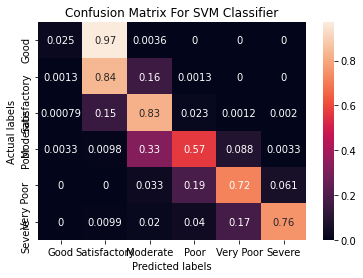

In [291]:
#Confusion Matrix for SVM

y_pred1= svm.predict(x1_test_rfecv)
y_actual1 = y1_test
labels = ['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']
cm = confusion_matrix(y_act1, y_pred1, labels, normalize='true')

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('Actual labels'); 
ax.set_title('Confusion Matrix For SVM Classifier'); 
ax.xaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']); 
ax.yaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe'])

4. KNN Classifier

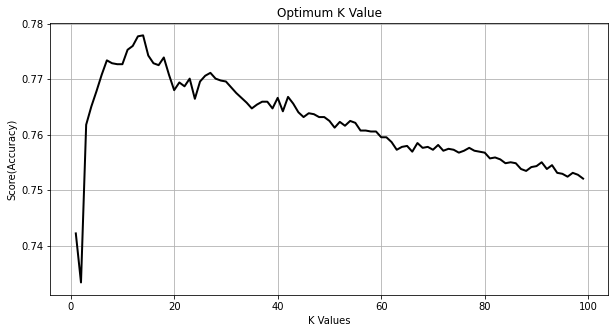

In [48]:
#Optimal K value for KNN Classifier

score = []
for each in range(1,100):
    knn_find = KNeighborsClassifier(n_neighbors = each)
    knn_find.fit(x1_train_rfecv,y1_train)
    score.append(knn_find.score(x1_test_rfecv,y1_test))

plt.figure(1, figsize=(10, 5))
plt.plot(range(1,100),score,color="black",linewidth=2)
plt.title("Optimum K Value")
plt.xlabel("K Values")
plt.ylabel("Score(Accuracy)")
plt.grid(True)
plt.show()

In [49]:
#KNN

knn = KNeighborsClassifier(n_neighbors = 15)

knn.fit(x1_train_rfecv,y1_train) 

generate_perform_measures(knn, x1_test_rfecv, y1_test)

Accuracy is:  0.7742718446601942
F1 score is:  0.7718925550266118
Precision is:  0.7732081225880393
Recall is:  0.7742718446601942


In [60]:
from sklearn.model_selection import cross_val_score

acc_knn = cross_val_score(estimator = knn, X = x1, y=y, cv=10)
print("Average Accuracies: ",np.mean(acc_knn))
print("Standart Deviation Accuracies: ",np.std(acc_knn))

Average Accuracies:  0.7081484049930652
Standart Deviation Accuracies:  0.055785396397915805


[Text(0, 0.5, 'Good'),
 Text(0, 1.5, 'Satisfactory'),
 Text(0, 2.5, 'Moderate'),
 Text(0, 3.5, 'Poor'),
 Text(0, 4.5, 'Very Poor'),
 Text(0, 5.5, 'Severe')]

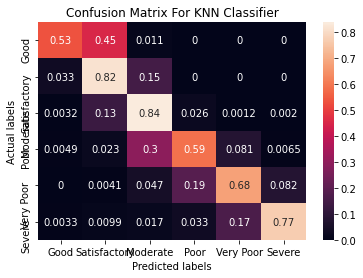

In [292]:
#Confusion Matrix

y_pred1= knn.predict(x1_test_rfecv)
y_actual1 = y1_test
labels = ['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']
cm = confusion_matrix(y_act1, y_pred1, labels, normalize='true')


ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('Actual labels'); 
ax.set_title('Confusion Matrix For KNN Classifier'); 
ax.xaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']); 
ax.yaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe'])

5. Random Forest Classifier

In [61]:
#Random Forest

random = RandomForestClassifier()

random.fit(x1_train_rfecv, y1_train)

generate_perform_measures(random, x1_test_rfecv, y1_test)

Accuracy is:  0.8110263522884882
F1 score is:  0.8096062622906085
Precision is:  0.8100433772071843
Recall is:  0.8110263522884882


In [62]:
#K fold cross validation for Random Forest Classifier
from sklearn.model_selection import cross_val_score

acc_ran = cross_val_score(estimator = random, X = x1, y=y, cv=10)
print("Average Accuracies: ",np.mean(acc_ran))
print("Standart Deviation Accuracies: ",np.std(acc_ran ))

Average Accuracies:  0.7515603328710125
Standart Deviation Accuracies:  0.03763094530076154


[Text(0, 0.5, 'Good'),
 Text(0, 1.5, 'Satisfactory'),
 Text(0, 2.5, 'Moderate'),
 Text(0, 3.5, 'Poor'),
 Text(0, 4.5, 'Very Poor'),
 Text(0, 5.5, 'Severe')]

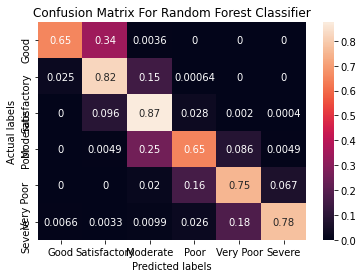

In [293]:
#Confusion Matrix

y_pred1= random.predict(x1_test_rfecv)
y_actual1 = y1_test
labels = ['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']
cm = confusion_matrix(y_act1, y_pred1, labels, normalize='true')

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('Actual labels'); 
ax.set_title('Confusion Matrix For Random Forest Classifier'); 
ax.xaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe']); 
ax.yaxis.set_ticklabels(['Good', 'Satisfactory', 'Moderate','Poor','Very Poor','Severe'])

In [74]:
#Visualizing accuracy score for different Supervised Learning Methods
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
Kfold_acc = [np.mean(acc_log),np.mean(acc_naive),np.mean(acc_svm), np.mean(acc_knn), np.mean(acc_ran)]

Algo_name=["Mulitnomial Logistic Regression","Naive Bayes","SVM", "K-NN","Random Forest"]
trace1 = go.Scatter(
    x = Algo_name,
    y = Kfold_acc,
    name = "Classifiers",
    marker = dict(color ='rgba(227,126,0,0.5)',
               line = dict(color='rgb(0,0,0)', width=3)),
    showlegend = True,
    cliponaxis = True,
    
)
go.Scatter()
data = [trace1]

layout = go.Layout(barmode = "group", 
                  xaxis= dict(title= 'Supervised Machine Learning Algorithms', ticklen= 5,zeroline= False),
              yaxis = dict(title= 'KFold Cross Validation accuracy Scores',ticklen= 5,zeroline= False))
fig = go.Figure(data = data, layout = layout)
iplot(fig)

**UNSUPERVISED** **LEARNING**

Clustering

In [275]:
#Silhouette Score
c1 = m2.copy()
m3 = c1.drop(['AQI_Bucket','City','Date','PM10','NO2','SO2', 'Year','Month','AQI'], axis =1)
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
matrix = pd.DataFrame(m3)
for n_clusters in range(2,10):
  kmeans = KMeans(init ='k-means++', n_clusters= n_clusters, n_init=100)
  kmeans.fit(matrix)
  clusters = kmeans.predict(matrix)
  silhouette_avg = silhouette_score(matrix, clusters)
  print("For n_clusters = ", n_clusters, "average silhouette score:", silhouette_avg)

For n_clusters =  2 average silhouette score: 0.5886465263275519
For n_clusters =  3 average silhouette score: 0.42704249977314535
For n_clusters =  4 average silhouette score: 0.2480606733802525
For n_clusters =  5 average silhouette score: 0.2662538587396491
For n_clusters =  6 average silhouette score: 0.27028447631211877
For n_clusters =  7 average silhouette score: 0.2774272190446317
For n_clusters =  8 average silhouette score: 0.27505466385494887
For n_clusters =  9 average silhouette score: 0.2626209406690181


In [268]:
#Elbow Method
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(matrix)
    sse.append(km.inertia_)

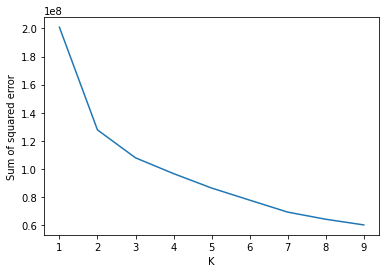

In [269]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [283]:
n_clusters = 3

kmeans = KMeans(init = 'k-means++', n_clusters = n_clusters, n_init = 30)
kmeans.fit(matrix)
answer = kmeans.predict(matrix)
answer

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [ ]:
matrix ['cluster']= answer
matrix.head()

matrix.info()

In [286]:
print(kmeans.cluster_centers_)


[[1.12547194e+02 3.37790528e+01 5.82140224e+01 4.43415852e+01
  5.31264727e+00 3.91920762e+01 4.03668076e+00 1.30539049e+01
  2.26133425e+00 1.99281996e+00]
 [4.48637419e+01 1.16252181e+01 2.24658846e+01 2.08109574e+01
  1.40886305e+00 3.28608026e+01 3.04448437e+00 6.83901196e+00
  2.37986436e+00 1.00241172e+00]
 [2.72751117e+02 5.64224488e+01 7.26072039e+01 5.10992079e+01
  3.49653087e+00 3.95057844e+01 4.80155047e+00 1.64756503e+01
  5.33356997e+00 1.02140518e-14]]


Text(0.5, 1.0, 'Cluster for PM2.5 and NO')

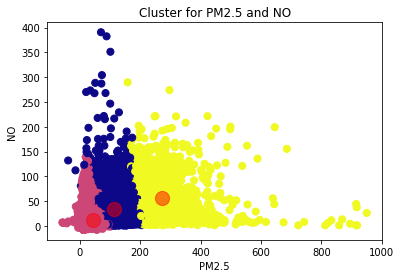

In [287]:

fig
plt.scatter(matrix['PM2.5'], matrix['NO'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('PM2.5')
plt.ylabel('NO')
plt.title('Cluster for PM2.5 and NO')


Text(0, 0.5, 'O3')

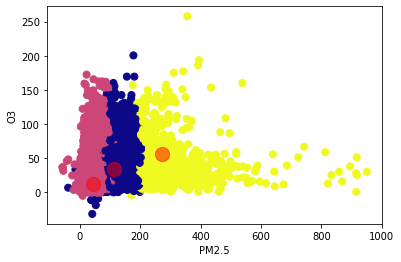

In [294]:
plt.scatter(matrix['PM2.5'], matrix['O3'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('PM2.5')
plt.ylabel('O3')

Text(0, 0.5, 'CO')

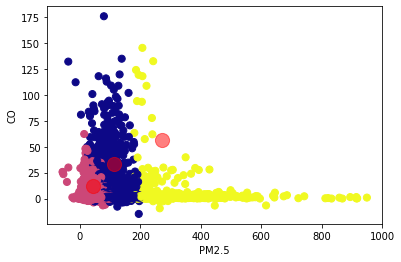

In [295]:
plt.scatter(matrix['PM2.5'], matrix['CO'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('PM2.5')
plt.ylabel('CO')

Text(0, 0.5, 'NO')

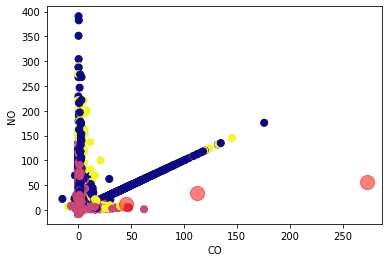

In [296]:
plt.scatter(matrix['CO'], matrix['NO'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('CO')
plt.ylabel('NO')


Text(0, 0.5, 'Benzene')

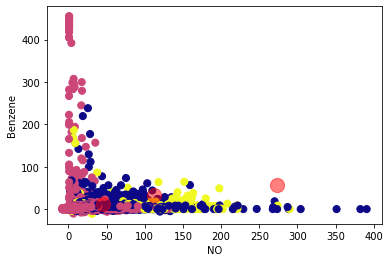

In [297]:
plt.scatter(matrix['NO'], matrix['Benzene'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('NO')
plt.ylabel('Benzene')


Text(0, 0.5, 'Benzene')

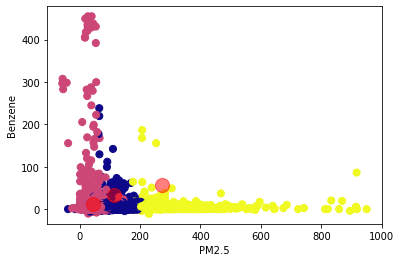

In [298]:
plt.scatter(matrix['PM2.5'], matrix['Benzene'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('PM2.5')
plt.ylabel('Benzene')


Text(0, 0.5, 'O3')

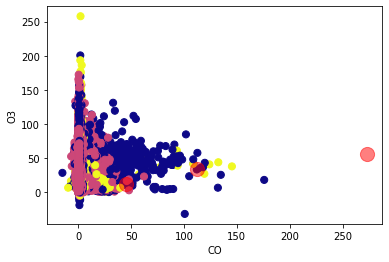

In [299]:
plt.scatter(matrix['CO'], matrix['O3'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('CO')
plt.ylabel('O3')


Text(0, 0.5, 'Xylene')

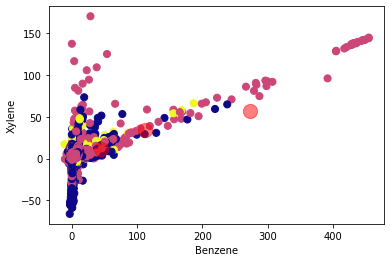

In [300]:
plt.scatter(matrix['Benzene'], matrix['Xylene'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('Benzene')
plt.ylabel('Xylene')


Text(0, 0.5, 'Toluene')

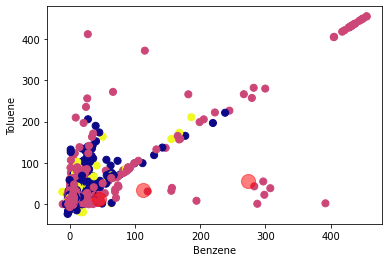

In [301]:
plt.scatter(matrix['Benzene'], matrix['Toluene'], c= answer, s =50, cmap = 'plasma')
center = kmeans.cluster_centers_
plt.scatter(center[:,0], center[:,1], c = 'red', s =200, alpha = 0.5)
plt.xlabel('Benzene')
plt.ylabel('Toluene')


**INTERESTING FINDINGS IN AQI DURING COVID RESTRICTIONS**

Converting "Date" into **datetime** format.

Extracting "Year" and "Month" from the "Date" variable and adding it to the main data.

In [ ]:
#Extracting year from DateTime format
m2["Date"] = pd.to_datetime(m2['Date'])
m2["Year"] = m2["Date"].dt.year
m2["Month"] = m2["Date"].dt.month

#Converting datatype for Year and Month
m2 = m2.astype({"Year":object})
m2 = m2.astype({"Month":object})


Comparison of different pollutants over the years

In [228]:
pollutants = ['NO2','NH3','CO','SO2','O3']

NameError: ignored

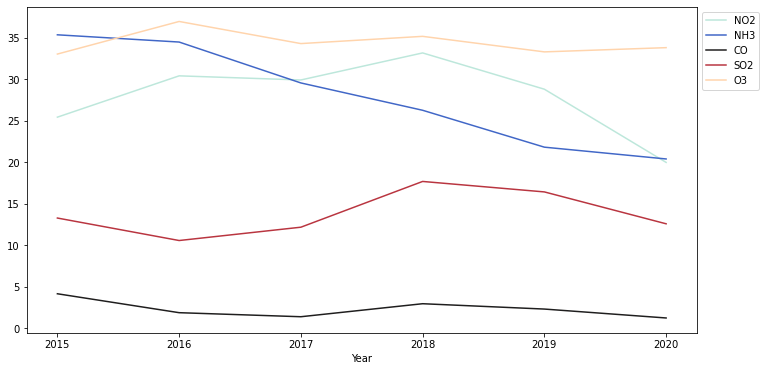

In [232]:
m2.groupby('Year')[pollutants].mean().plot(figsize=(12,6), cmap='icefire')
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.xticks(np.arange(12), mth_dic.values())

Comparison between the AQI for the entire 2019 year and the first six months of 2020 for four major metropolitian cities of "Ahmedabad", "Bengaluru", "Delhi" and "Mumbai".

In [307]:
cities = ['Ahmedabad','Delhi','Bengaluru','Mumbai']

filtered_m2 = m2[m2['Date'] >= '2019-01-01']
AQI = filtered_m2[filtered_m2.City.isin(cities)][['Date','City','AQI','AQI_Bucket','NO2','NO','NOx']]
AQI.head()

,Date,City,AQI,AQI_Bucket,NO2,NO,NOx
1461,2019-01-01,Ahmedabad,1474.0,Severe,111.56,63.03,100.04
1462,2019-01-02,Ahmedabad,1246.0,Severe,107.46,59.56,129.87
1463,2019-01-03,Ahmedabad,1719.0,Severe,75.82,119.68,88.04
1464,2019-01-04,Ahmedabad,1264.0,Severe,95.29,57.92,54.93
1465,2019-01-05,Ahmedabad,1127.0,Severe,111.04,63.86,61.99


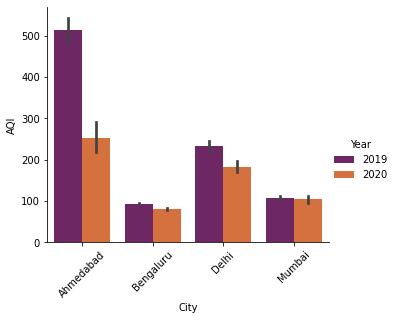

In [310]:
yearly_AQI = filtered_m2[filtered_m2.City.isin(cities)][['Date','City','AQI','AQI_Bucket','Year']]
chart = sns.catplot(x="City", y="AQI", hue="Year", data=yearly_AQI, height=4, aspect=1.2, kind="bar", palette="inferno");
chart.set_xticklabels(rotation=45);

Observation in the drop of AQI levels of metropolitian cities of "Ahmedabad", "Bengaluru", "Delhi" and "Mumbai after covid lockdown restrictions were imposed on 25th March, 2020.

In [221]:
AQI_pivot = AQI.pivot(index='Date', columns='City', values='AQI')

from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=4, cols=1,
    #specs=[[{}, {}],
          # [{"colspan": 6}, None]],
    subplot_titles=("Ahmedabad","Bengaluru","Delhi","Mumbai"))

fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Ahmedabad'],
                    marker=dict(color=AQI_pivot['Ahmedabad'],coloraxis="coloraxis1")),
              1, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Bengaluru'],
                    marker=dict(color=AQI_pivot['Bengaluru'], coloraxis="coloraxis1")),
              2, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Delhi'],
                    marker=dict(color=AQI_pivot['Delhi'], coloraxis="coloraxis1")),
              3, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Mumbai'],
                    marker=dict(color=AQI_pivot['Mumbai'], coloraxis="coloraxis1")),
              4, 1)

fig.update_layout(coloraxis=dict(colorscale='Temps'),showlegend=False,title_text="AQI Levels")

fig.update_layout(plot_bgcolor='white')

fig.update_layout( width=800,height=800,shapes=[
      dict(
      type= 'line',
      yref= 'paper', y0= 0, y1= 1,
      xref= 'x', x0= '2020-03-25', x1= '2020-03-25'
    )
])

fig.show()

Comparison of NO2 concentration for the years 2019 and 2020

In [ ]:
new_2020 = m2.loc[m2["Year"] == 2020]
new_2019 = m2.loc[m2["Year"] == 2019]
new = pd.concat([new_2019, new_2020])

AQI_new = new[new.City.isin(cities)]
AQI_new.info()

In [ ]:
chart = sns.catplot(x="City", y="NO2", hue="Year", data=AQI_new, height=5, aspect=1.1, kind="bar", palette="muted");
chart.set_xticklabels(rotation=45);